In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs_pure
import loglike 
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 1/12     # Total time


# -----------------------------
# PARIS global context (picklable functions require module scope)
# -----------------------------
_PARIS_EARLY_STOP_HIT = False

# Fisher-parallelotope affine prior (primary for this script)
_PARIS_AFFINE_CENTER = None       # type: Optional[np.ndarray]
_PARIS_AFFINE_Q = None            # type: Optional[np.ndarray]
_PARIS_AFFINE_B = None            # type: Optional[np.ndarray]
# _PARIS_DIM = None                 # type: Optional[int]


print(f"Using dt = {dt} seconds, T = {T} years")



print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs_pure.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike.LogLike(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")
# make this from data_snr
_TARGET_LOGLIKE = 3.329
# REVERSE TEMP for annealing
# supposed to be 1/temp if we're going with the right nomenclature 
# so supposed to be reversetemp
temp = 1

def log_density(params):
    global _PARIS_EARLY_STOP_HIT
    params = np.asarray(params)

    def eval_one(x):
        global _PARIS_EARLY_STOP_HIT
        if _PARIS_EARLY_STOP_HIT:
            return float('-inf')
        try:
            logm1, logm2, a, p0, e0 = x
            m1 = 10**logm1
            m2 = 10**logm2

            fstat = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))            
        except Exception:
            return float('-inf')
        
        if fstat >= _TARGET_LOGLIKE:
            _PARIS_EARLY_STOP_HIT = True
            try:
                print(f"[EARLY-STOP] SNR {fstat:.6f} >= {_TARGET_LOGLIKE}; future calls => -inf")
            except Exception:
                pass

        return fstat
        
    if params.ndim == 1:
        return eval_one(params)
    out = np.zeros(params.shape[0], dtype=float)
    for i in range(params.shape[0]):
        out[i] = eval_one(params[i])
    return out

Using dt = 10 seconds, T = 0.08333333333333333 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 3.329956127385638
Setting up log_density and prior functions...


In [5]:
# from previous resume run
best_fit = [5.99924515, 1.00389791, 0.69519314, 9.02648957, 0.39784083]
log_density(best_fit)

0.4082884669607745

In [6]:
from scipy.optimize import minimize

def neg_logden(x):
    val = log_density(np.array([x]))[0]
    return -val if np.isfinite(val) else 1e10

result = minimize(neg_logden, x0=best_fit, method='Nelder-Mead',
                  options={'xatol':1e-6, 'fatol':1e-6, 'maxiter':2000, 
                           'adaptive':True, 'disp':True})

best_fit_new = result.x
print('peak:', best_fit_new)
print('logden:', -result.fun)

Optimization terminated successfully.
         Current function value: -3.319532
         Iterations: 270
         Function evaluations: 607
peak: [5.99927385 1.00396824 0.69517519 9.02632232 0.39784027]
logden: 3.3195317356679954


# connection plot

In [7]:
# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
import loglike 
loglike_nont = loglike.LogLike(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_nont.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)

Done initializing loglike class.
Calculating SNR...
SNR calculated: 3.329956127385638


In [8]:
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]

In [10]:
maxldpt = np.array([5.99927385, 1.00396824, 0.69517519, 9.02632232, 0.39784027])


In [11]:
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 100
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = maxldpt[:, np.newaxis] + t_values * (true_pt - maxldpt)[:, np.newaxis]


In [12]:
def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = loglike 

    return log_likes

In [13]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [14]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()
logden_theory_proc1

array([3.31953171, 3.31953736, 3.31953809, 3.31953418, 3.31952595,
       3.31951367, 3.31949764, 3.31947813, 3.31945541, 3.31942973,
       3.31940139, 3.31937059, 3.31933762, 3.31930271, 3.31926606,
       3.31922795, 3.31918857, 3.31914813, 3.31910687, 3.31906495,
       3.3190226 , 3.31898002, 3.31893736, 3.31889483, 3.31885258,
       3.31881076, 3.31876955, 3.31872913, 3.3186896 , 3.31865115,
       3.31861387, 3.3185779 , 3.31854339, 3.3185104 , 3.31847911,
       3.31844958, 3.31842189, 3.31839618, 3.3183725 , 3.31835092,
       3.31833157, 3.31831445, 3.31829962, 3.31828721, 3.31827721,
       3.31826964, 3.31826456, 3.31826202, 3.31826201, 3.31826453,
       3.31826963, 3.3182773 , 3.31828754, 3.31830032, 3.31831566,
       3.31833347, 3.31835379, 3.31837656, 3.31840171, 3.31842925,
       3.3184591 , 3.31849115, 3.31852538, 3.31856175, 3.3186001 ,
       3.31864039, 3.31868253, 3.3187264 , 3.31877192, 3.31881895,
       3.3188674 , 3.31891712, 3.31896798, 3.31901988, 3.31907

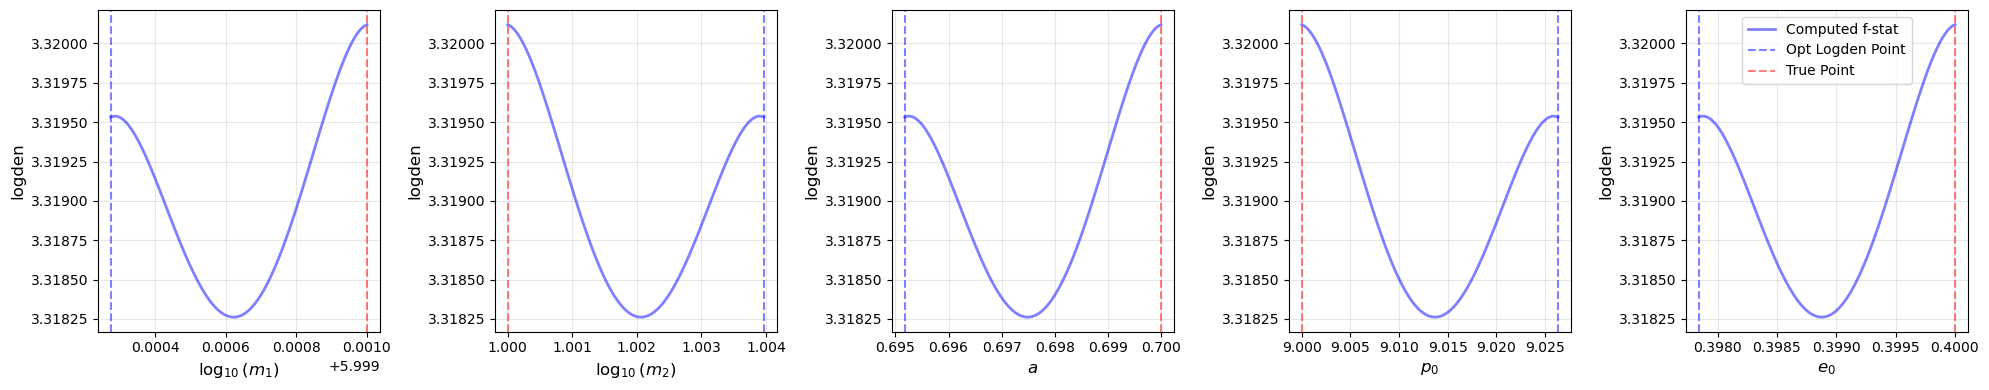

In [16]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(maxldpt[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Opt Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
